# Dự đoán Trạng thái Khoản vay (Loan Status Prediction) - Phân loại
## Mục tiêu:
  Xây dựng mô hình Classification để dự đoán hồ sơ **Declined (Từ chối)**, phục vụ cho việc chấm điểm rủi ro tín dụng. Đặc biệt chú trọng vào khả năng tìm ra và dự đoán đúng các hồ sơ rủi ro tiềm ẩn.

 ## Độ Đo Đánh Giá (Metrics):
   - **Precision (Declined)**: Khả năng dự đoán đúng hồ sơ rủi ro (giảm False Positive)
   - **Recall (Declined)**: Khả năng tìm thấy tất cả hồ sơ rủi ro (giảm False Negative)
   - **ROC AUC Score**: Hiệu suất tổng thể."

In [1]:
# 1.1 Import các thư viện cần thiết
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Import thành công!")


Import thành công!


In [2]:
# 1.2 Nạp và Khám phá Dữ liệu
df = pd.read_csv(r'C:\Users\MY LAPTOP\Downloads\loan_applications.csv')

print("========== THÔNG TIN DỮ LIỆU ==========")
print(f"Số lượng mẫu: {len(df)}")
print(f"Số lượng features: {df.shape[1]}")
print(f"\nCác cột:")
print(df.columns.tolist())



========== THÔNG TIN DỮ LIỆU ==========
Số lượng mẫu: 50000
Số lượng features: 16

Các cột:
['application_id', 'customer_id', 'application_date', 'loan_type', 'loan_amount_requested', 'loan_tenure_months', 'purpose_of_loan', 'monthly_income', 'cibil_score', 'existing_emis_monthly', 'property_ownership_status', 'residential_address', 'applicant_age', 'gender', 'loan_status', 'fraud_flag']


In [3]:
# 2. Phân tích dữ liệu khám phá (EDA)
# Thông tin dữ liệu & xử lý nhãn
print(df.info())

# Loại bỏ Pending
df = df[df['loan_status'].isin(['Approved', 'Declined'])].copy()

# Encode target
df['Target'] = df['loan_status'].apply(lambda x: 1 if x == 'Declined' else 0)
print(df['loan_status'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   application_id             50000 non-null  object
 1   customer_id                50000 non-null  object
 2   application_date           50000 non-null  object
 3   loan_type                  50000 non-null  object
 4   loan_amount_requested      50000 non-null  int64 
 5   loan_tenure_months         50000 non-null  int64 
 6   purpose_of_loan            50000 non-null  object
 7   monthly_income             50000 non-null  int64 
 8   cibil_score                50000 non-null  int64 
 9   existing_emis_monthly      50000 non-null  int64 
 10  property_ownership_status  50000 non-null  object
 11  residential_address        50000 non-null  object
 12  applicant_age              50000 non-null  int64 
 13  gender                     50000 non-null  object
 14  loan_s

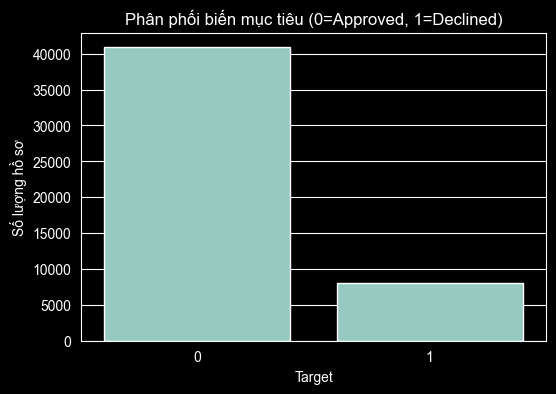

In [4]:
# Trực quan phân phối biến mục tiêu
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df)
plt.title('Phân phối biến mục tiêu (0=Approved, 1=Declined)')
plt.xlabel('Target')
plt.ylabel('Số lượng hồ sơ')
plt.show()


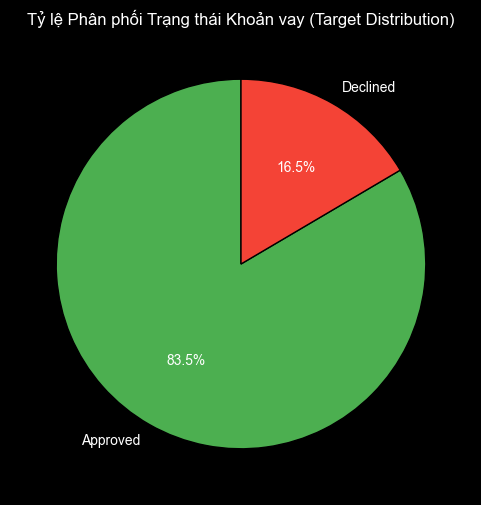

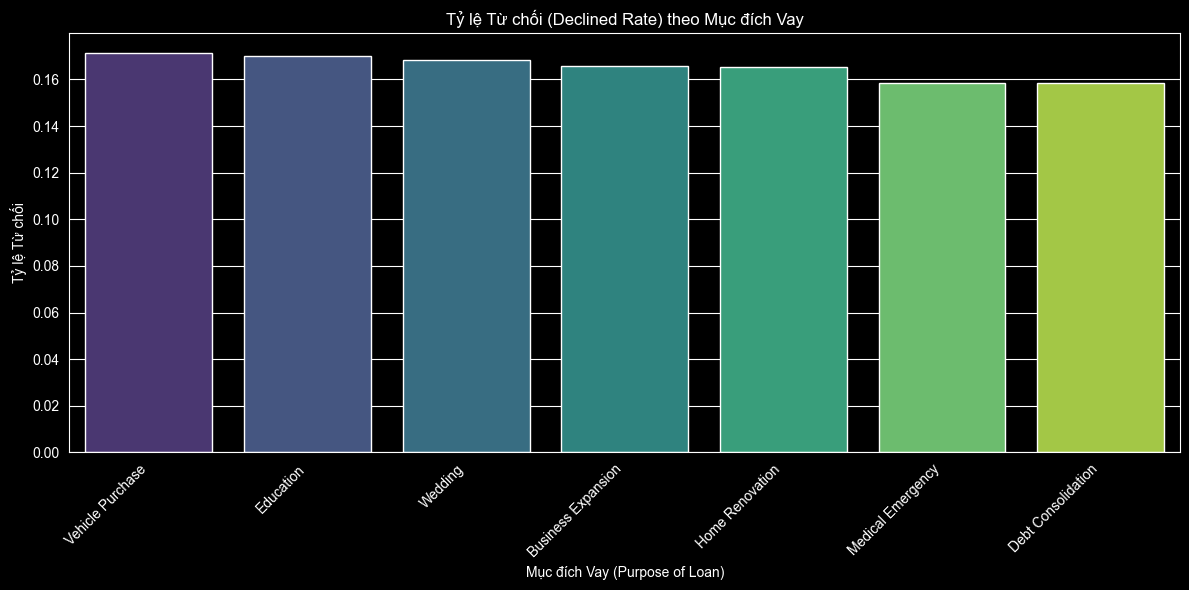

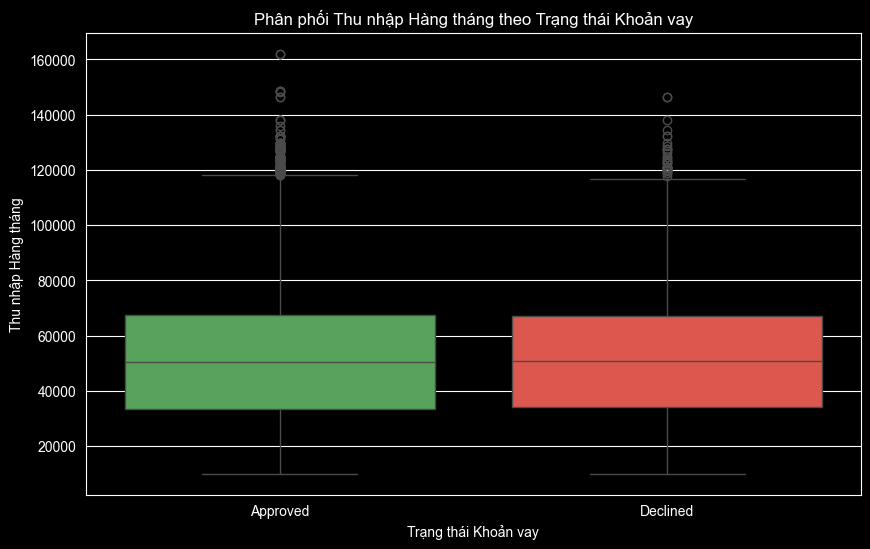

In [5]:
#  Trực quan hóa dữ liệu ---

# a) Thống kê tỷ lệ Approved vs Declined (Tương đương Biểu đồ tròn)
plt.figure(figsize=(6, 6))
df['loan_status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4CAF50', '#F44336'],
    wedgeprops={'edgecolor': 'black'}
)
plt.title('Tỷ lệ Phân phối Trạng thái Khoản vay (Target Distribution)')
plt.ylabel('')
plt.show()

# b) Phân tích Tỷ lệ từ chối theo các Biến phân loại (Tương đương Biểu đồ cột theo Quận)
# Ví dụ 1: Purpose of Loan
plt.figure(figsize=(12, 6))
decline_rates_purpose = df.groupby('purpose_of_loan')['Target'].mean().sort_values(ascending=False)
sns.barplot(
    x=decline_rates_purpose.index,
    y=decline_rates_purpose.values,
    palette='viridis'
)
plt.title('Tỷ lệ Từ chối (Declined Rate) theo Mục đích Vay')
plt.xlabel('Mục đích Vay (Purpose of Loan)')
plt.ylabel('Tỷ lệ Từ chối')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# c) Phân tích Tỷ lệ từ chối theo Biến số (Tương đương Thống kê theo Năm)
# Ví dụ: Mối quan hệ giữa Thu nhập (Monthly Income) và Trạng thái Vay
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='loan_status',
    y='monthly_income',
    data=df,
    palette={'Approved': '#4CAF50', 'Declined': '#F44336'}
)
plt.title('Phân phối Thu nhập Hàng tháng theo Trạng thái Khoản vay')
plt.xlabel('Trạng thái Khoản vay')
plt.ylabel('Thu nhập Hàng tháng')
plt.show()

In [6]:
# 3. Tiền xử lý dữ liệu & Feature Engineering
NUMERICAL_FEATURES = [
    'monthly_income',
    'loan_amount_requested',
    'applicant_age'
]

CATEGORICAL_FEATURES = [
    'gender',
    'purpose_of_loan',
    'residential_address'
]

X = df[NUMERICAL_FEATURES + CATEGORICAL_FEATURES]
y = df['Target']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (34281, 6)
Test size: (14693, 6)


In [7]:
# 3. Huấn luyện & Đánh giá mô hình
# Hàm đánh giá chung
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, y_proba):.4f}")
    print(classification_report(y_true, y_pred))

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_proba)
    }


In [8]:
# Mô hình 1 Random Forest
rf_model = Pipeline([
('preprocessor', preprocessor),
('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])


rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]
rf_metrics = evaluate_model('Random Forest', y_test, y_pred_rf, y_proba_rf)


===== Random Forest =====
Accuracy: 0.7822
Precision: 0.1701
Recall: 0.0820
ROC AUC: 0.5019
              precision    recall  f1-score   support

           0       0.84      0.92      0.88     12265
           1       0.17      0.08      0.11      2428

    accuracy                           0.78     14693
   macro avg       0.50      0.50      0.49     14693
weighted avg       0.73      0.78      0.75     14693



In [9]:
# Mô hình 2 XGBoost
xgb_model = Pipeline([
('preprocessor', preprocessor),
('classifier', xgb.XGBClassifier(eval_metric='logloss', random_state=42))
])


xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]
xgb_metrics = evaluate_model('XGBoost', y_test, y_pred_xgb, y_proba_xgb)


===== XGBoost =====
Accuracy: 0.8335
Precision: 0.2188
Recall: 0.0029
ROC AUC: 0.4916
              precision    recall  f1-score   support

           0       0.83      1.00      0.91     12265
           1       0.22      0.00      0.01      2428

    accuracy                           0.83     14693
   macro avg       0.53      0.50      0.46     14693
weighted avg       0.73      0.83      0.76     14693



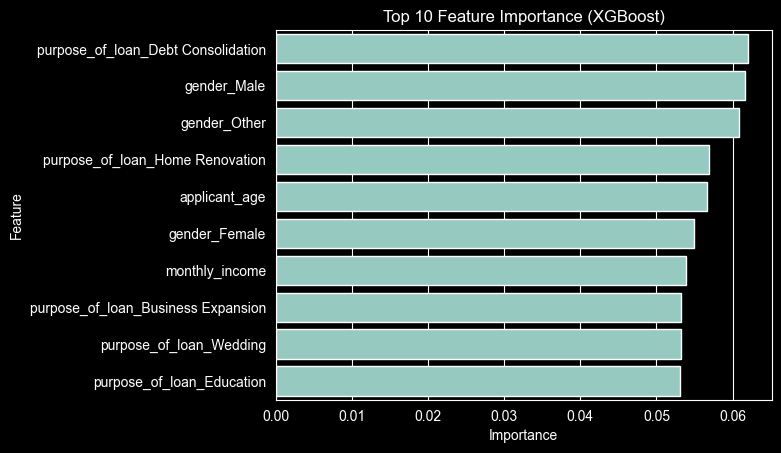

In [10]:
# 4. Feature Importance (XGBoost)
feature_names = (
NUMERICAL_FEATURES +
list(xgb_model['preprocessor']
.named_transformers_['cat']
.get_feature_names_out(CATEGORICAL_FEATURES))
)


importance_df = pd.DataFrame({
'Feature': feature_names,
'Importance': xgb_model['classifier'].feature_importances_
}).sort_values('Importance', ascending=False).head(10)


sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top 10 Feature Importance (XGBoost)')
plt.show()

--------------------------------------------------------------------------------
BẢNG TỔNG KẾT METRICS
           Model  Accuracy  Precision    Recall   ROC AUC
0  Random Forest  0.782209   0.170085  0.081960  0.501935
1        XGBoost  0.833526   0.218750  0.002883  0.491556
--------------------------------------------------------------------------------

PHÂN TÍCH DỰ ĐOÁN THỰC TẾ (XGBoost)

2. TỔNG SỐ FALSE NEGATIVES (Bỏ sót rủi ro) của XGBoost: 2421
10 hồ sơ FN có xác suất Declined cao nhất (đáng lẽ phải dự đoán đúng):


,Actual_Status,RF_Predicted,XGB_Predicted,XGB_Prob_Declined
14167,Declined,Approved,Approved,0.498348
2026,Declined,Approved,Approved,0.484693
12333,Declined,Approved,Approved,0.470966
2057,Declined,Declined,Approved,0.467891
13309,Declined,Declined,Approved,0.462517
5579,Declined,Declined,Approved,0.438890
14430,Declined,Approved,Approved,0.428150
2217,Declined,Approved,Approved,0.421720
5505,Declined,Declined,Approved,0.416180
357,Declined,Approved,Approved,0.414528



3. TỔNG SỐ TRUE POSITIVES (Nhận diện rủi ro đúng) của XGBoost: 7
10 hồ sơ TP có xác suất Declined cao nhất:


,Actual_Status,RF_Predicted,XGB_Predicted,XGB_Prob_Declined
978,Declined,Approved,Declined,0.726936
1558,Declined,Declined,Declined,0.658665
4741,Declined,Approved,Declined,0.650490
12151,Declined,Declined,Declined,0.628998
5694,Declined,Approved,Declined,0.609375
9962,Declined,Approved,Declined,0.572358
11601,Declined,Declined,Declined,0.569347


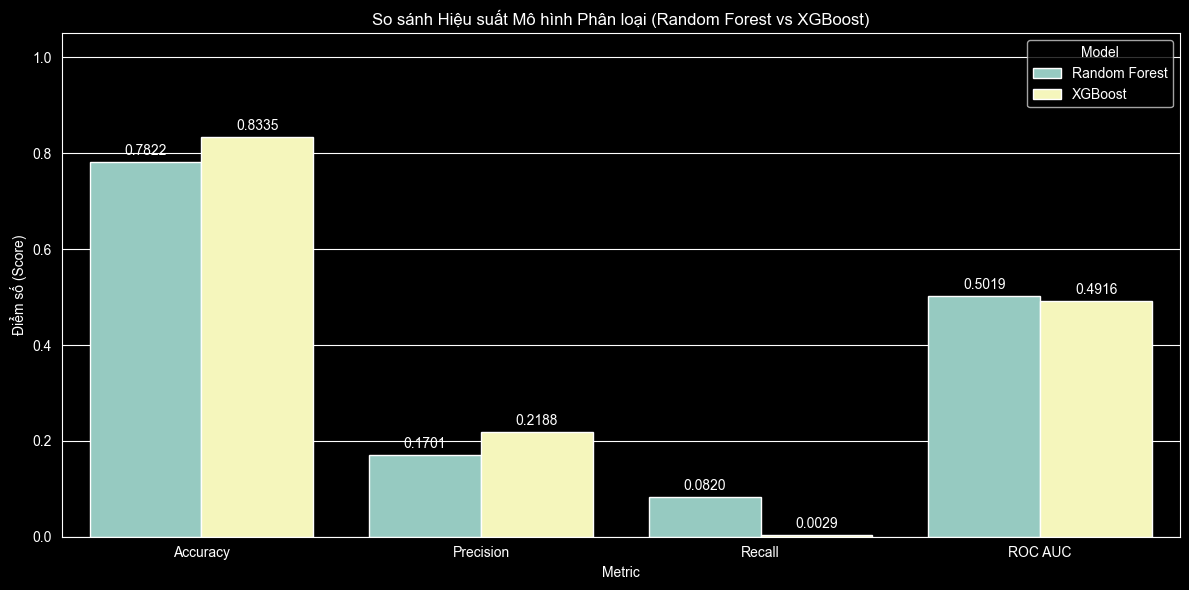

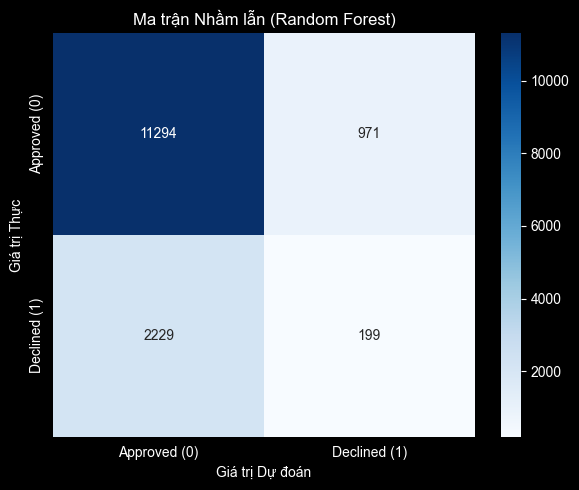

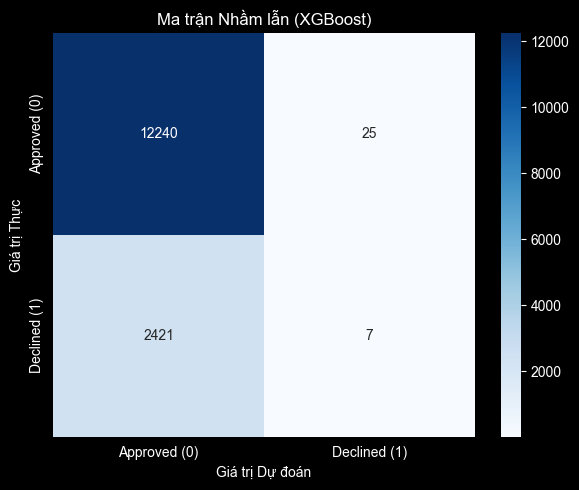

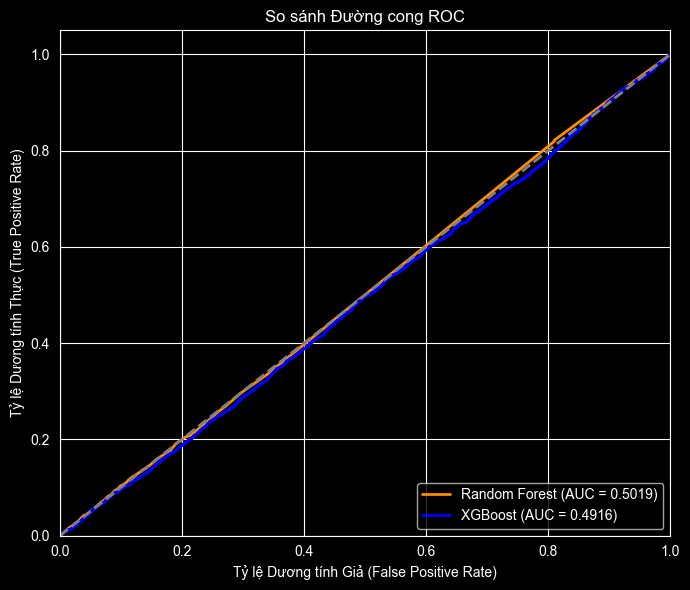

In [15]:


# ==============================================================================
# BƯỚC 1: TẠO CÁC BIẾN DỰ ĐOÁN (Khắc phục lỗi NameError)
# ==============================================================================

# 1. Random Forest
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1] # Xác suất cho lớp 1 ('Declined')

# 2. XGBoost
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1] # Xác suất cho lớp 1 ('Declined')

# 3. Cập nhật DataFrame kết quả (từ code gốc của bạn)

results = pd.DataFrame([
    ['Random Forest', *rf_metrics.values()],
    ['XGBoost', *xgb_metrics.values()]
], columns=['Model', 'Accuracy', 'Precision', 'Recall', 'ROC AUC'])
print("--------------------------------------------------------------------------------")
print("BẢNG TỔNG KẾT METRICS")
print(results)
print("--------------------------------------------------------------------------------")

# ==============================================================================
# BƯỚC 2: HÀM VẼ BIỂU ĐỒ TRỰC QUAN HÓA
# ==============================================================================

def plot_confusion_matrix(y_true, y_pred, model_name, filename):
    """Vẽ Ma trận Nhầm lẫn (Confusion Matrix)"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Approved (0)', 'Declined (1)'],
                yticklabels=['Approved (0)', 'Declined (1)'])
    plt.title(f'Ma trận Nhầm lẫn ({model_name})')
    plt.ylabel('Giá trị Thực')
    plt.xlabel('Giá trị Dự đoán')
    plt.tight_layout()
    plt.savefig(filename)


def plot_roc_curve(y_true, y_prob_rf, y_prob_xgb, filename):
    """Vẽ Đường cong ROC (ROC Curve) so sánh 2 mô hình"""
    fpr_rf, tpr_rf, _ = roc_curve(y_true, y_prob_rf)
    roc_auc_rf = auc(fpr_rf, tpr_rf)

    fpr_xgb, tpr_xgb, _ = roc_curve(y_true, y_prob_xgb)
    roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2,
             label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
    plt.plot(fpr_xgb, tpr_xgb, color='blue', lw=2,
             label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tỷ lệ Dương tính Giả (False Positive Rate)')
    plt.ylabel('Tỷ lệ Dương tính Thực (True Positive Rate)')
    plt.title('So sánh Đường cong ROC')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename)



# ==============================================================================
# BƯỚC 3: THỰC HIỆN TRỰC QUAN HÓA
# ==============================================================================

# 3.1. Biểu đồ So sánh Metrics (Bar Chart)
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.4f', padding=3)
plt.title('So sánh Hiệu suất Mô hình Phân loại (Random Forest vs XGBoost)')
plt.ylabel('Điểm số (Score)')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('model_comparison_metrics_bar_chart.png')
# plt.show()

# 3.2. Ma trận Nhầm lẫn
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest', 'cm_random_forest.png')
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost', 'cm_xgboost.png')

# 3.3. Đường cong ROC
plot_roc_curve(y_test, y_prob_rf, y_prob_xgb, 'roc_curve_comparison.png')


# ==============================================================================
# BƯỚC 4: PHÂN TÍCH DỰ ĐOÁN THỰC TẾ VÀ LỖI (ĐỊNH TÍNH)
# ==============================================================================

print("\n===================================================================")
print("PHÂN TÍCH DỰ ĐOÁN THỰC TẾ (XGBoost)")
print("===================================================================")

# 4.1. Gộp kết quả dự đoán và dữ liệu thực tế vào một DataFrame

comparison_df = pd.DataFrame({
    'Actual_Status': y_test.map({0: 'Approved', 1: 'Declined'}).values,
    'RF_Predicted': pd.Series(y_pred_rf).map({0: 'Approved', 1: 'Declined'}).values,
    'XGB_Predicted': pd.Series(y_pred_xgb).map({0: 'Approved', 1: 'Declined'}).values,
    'XGB_Prob_Declined': pd.Series(y_prob_xgb).values
})

# 4.2. PHÂN TÍCH LỖI NGHIÊM TRỌNG (FALSE NEGATIVES - Bỏ sót rủi ro)
false_negatives = comparison_df[
    (comparison_df['Actual_Status'] == 'Declined') &
    (comparison_df['XGB_Predicted'] == 'Approved')
].sort_values(by='XGB_Prob_Declined', ascending=False)

print(f"\n2. TỔNG SỐ FALSE NEGATIVES (Bỏ sót rủi ro) của XGBoost: {len(false_negatives)}")
print("10 hồ sơ FN có xác suất Declined cao nhất (đáng lẽ phải dự đoán đúng):")


display(false_negatives.head(10))


# 4.3. PHÂN TÍCH DỰ ĐOÁN ĐÚNG RỦI RO (TRUE POSITIVES)
true_positives = comparison_df[
    (comparison_df['Actual_Status'] == 'Declined') &
    (comparison_df['XGB_Predicted'] == 'Declined')
].sort_values(by='XGB_Prob_Declined', ascending=False)

print(f"\n3. TỔNG SỐ TRUE POSITIVES (Nhận diện rủi ro đúng) của XGBoost: {len(true_positives)}")
print("10 hồ sơ TP có xác suất Declined cao nhất:")


display(true_positives.head(10))

